# Analyse du corpus politique français
Analyse statistique et visuelle par orientation politique (Y) et par thème.

In [79]:
import json
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

# Création dossier figures
os.makedirs('figures', exist_ok=True)

THEMES = ['securite', 'ecologie', 'economie', 'mobilite', 'education', 'sociale']
THEME_LABELS = {'securite':'Sécurité','ecologie':'Écologie','economie':'Économie',
                'mobilite':'Mobilité','education':'Éducation','sociale':'Social'}

LABEL_NAMES = {'ED':'Extrême droite','D':'Droite','C':'Centre','G':'Gauche','EG':'Extrême gauche'}
ORDER = ['EG', 'G', 'C', 'D', 'ED']

COLORS = {
    'ED': '#1a1a2e',
    'D':  '#1e6fd9',
    'C':  '#f5a623',
    'G':  '#e8453c',
    'EG': '#8B0000',
}

# Chargement unique
with open('data/corpus.json', encoding='utf-8') as f:
    all_docs = json.load(f)

print(f'Total documents chargés : {len(all_docs)}')
print(Counter(d['y'] for d in all_docs))

Total documents chargés : 51
Counter({'C': 12, 'EG': 11, 'ED': 10, 'D': 10, 'G': 8})


## 1. Construction du DataFrame

In [80]:
rows = []
for d in all_docs:
    themes = d.get('themes', {})
    non_classe = d.get('non_classe', '')
    theme_tokens = {t: len(themes.get(t, '').split()) for t in THEMES}
    total_tokens = sum(theme_tokens.values()) + len(non_classe.split())
    classified_tokens = sum(theme_tokens.values())
    row = {
        'id': d['id'],
        'y': d['y'],
        'source': d.get('source', ''),
        'parti': d.get('parti', 'N/A'),
        'candidat': d.get('candidat', 'N/A'),
        'total_tokens': total_tokens,
        'classified_tokens': classified_tokens,
        'non_classe_tokens': len(non_classe.split()),
        'coverage_pct': round(classified_tokens / total_tokens * 100, 1) if total_tokens > 0 else 0,
        **{f'tokens_{t}': theme_tokens[t] for t in THEMES}
    }
    rows.append(row)

df = pd.DataFrame(rows)
df['y'] = pd.Categorical(df['y'], categories=ORDER, ordered=True)
df['label'] = df['y'].map(LABEL_NAMES)
df = df.sort_values('y').reset_index(drop=True)

df[['y','label','parti','total_tokens','coverage_pct'] + [f'tokens_{t}' for t in THEMES]]

,y,label,parti,total_tokens,coverage_pct,tokens_securite,tokens_ecologie,tokens_economie,tokens_mobilite,tokens_education,tokens_sociale
0,EG,Extrême gauche,NPA,1355,85.5,249,94,491,67,21,236
1,EG,Extrême gauche,Lutte Ouvrière,731,87.1,170,0,197,17,0,253
2,EG,Extrême gauche,Lutte Ouvrière,734,87.2,173,0,197,17,0,253
3,EG,Extrême gauche,Lutte Ouvrière,1538,77.0,164,60,638,142,20,160
4,EG,Extrême gauche,Lutte Ouvrière,593,89.5,133,0,185,0,14,199
5,EG,Extrême gauche,La France Insoumise,556,77.7,56,77,77,61,41,120
6,EG,Extrême gauche,Lutte Ouvrière,597,89.4,133,0,207,0,0,194
7,EG,Extrême gauche,Lutte Ouvrière,593,89.5,133,0,185,0,14,199
8,EG,Extrême gauche,La France Insoumise,831,94.8,83,293,167,73,61,111
9,EG,Extrême gauche,La France Insoumise,1413,71.4,59,191,224,0,86,449


## 2. Taille du corpus

                nb_docs  total_tokens  moy_tokens  min_tokens  max_tokens  coverage_moy
Extrême gauche       11         10571       961.0         556        1630          80.4
Gauche                8         10314      1289.2         768        1988          72.3
Centre               12         10581       881.8           0        1452          61.0
Droite               10          8062       806.2           0        1431          67.7
Extrême droite       10          7419       741.9         229        1728          73.5


C:\Users\antoc\AppData\Local\Temp\ipykernel_37320\3565530938.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(labels_plot, rotation=20, ha='right')
C:\Users\antoc\AppData\Local\Temp\ipykernel_37320\3565530938.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels_plot, rotation=20, ha='right')
C:\Users\antoc\AppData\Local\Temp\ipykernel_37320\3565530938.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(labels_plot, rotation=20, ha='right')


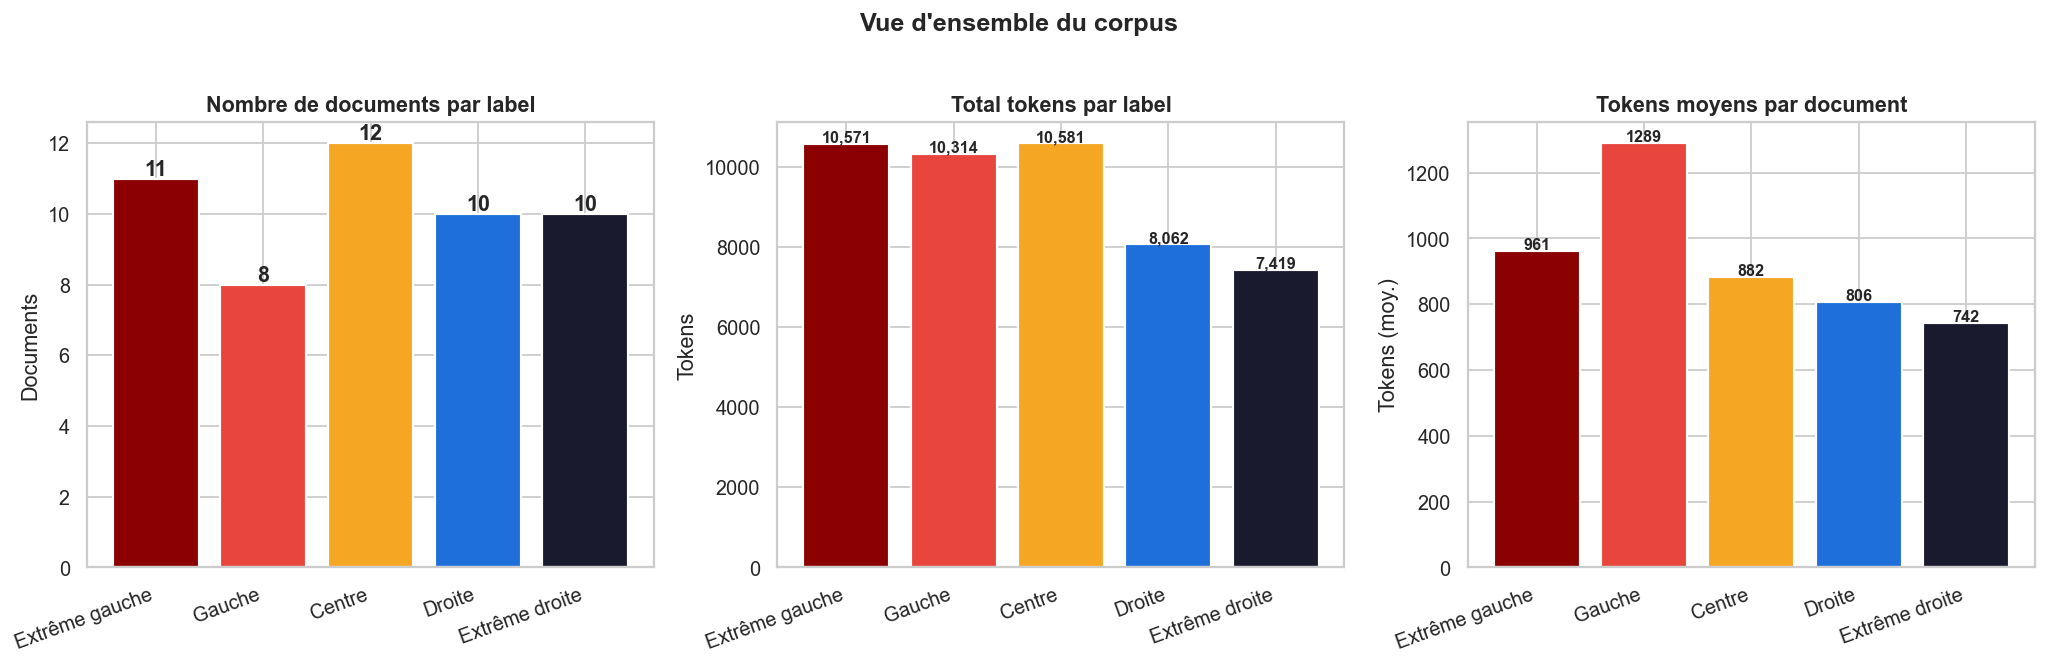

In [81]:
stats = df.groupby('y', observed=True).agg(
    nb_docs=('id', 'count'),
    total_tokens=('total_tokens', 'sum'),
    moy_tokens=('total_tokens', 'mean'),
    min_tokens=('total_tokens', 'min'),
    max_tokens=('total_tokens', 'max'),
    coverage_moy=('coverage_pct', 'mean'),
).round(1)
stats.index = [LABEL_NAMES[y] for y in stats.index]
print(stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels_plot = stats.index.tolist()
colors_plot = [COLORS[y] for y in ORDER]

axes[0].bar(labels_plot, stats['nb_docs'], color=colors_plot, edgecolor='white', linewidth=1.2)
axes[0].set_title('Nombre de documents par label', fontweight='bold')
axes[0].set_ylabel('Documents')
for i, v in enumerate(stats['nb_docs']):
    axes[0].text(i, v + 0.1, str(int(v)), ha='center', fontweight='bold')
axes[0].set_xticklabels(labels_plot, rotation=20, ha='right')

axes[1].bar(labels_plot, stats['total_tokens'], color=colors_plot, edgecolor='white', linewidth=1.2)
axes[1].set_title('Total tokens par label', fontweight='bold')
axes[1].set_ylabel('Tokens')
for i, v in enumerate(stats['total_tokens']):
    axes[1].text(i, v + 50, f'{int(v):,}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticklabels(labels_plot, rotation=20, ha='right')

axes[2].bar(labels_plot, stats['moy_tokens'], color=colors_plot, edgecolor='white', linewidth=1.2)
axes[2].set_title('Tokens moyens par document', fontweight='bold')
axes[2].set_ylabel('Tokens (moy.)')
for i, v in enumerate(stats['moy_tokens']):
    axes[2].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_xticklabels(labels_plot, rotation=20, ha='right')

plt.suptitle("Vue d'ensemble du corpus", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/corpus_resume.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Distribution des tokens par document (boxplot)

C:\Users\antoc\AppData\Local\Temp\ipykernel_37320\1052888818.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=10)


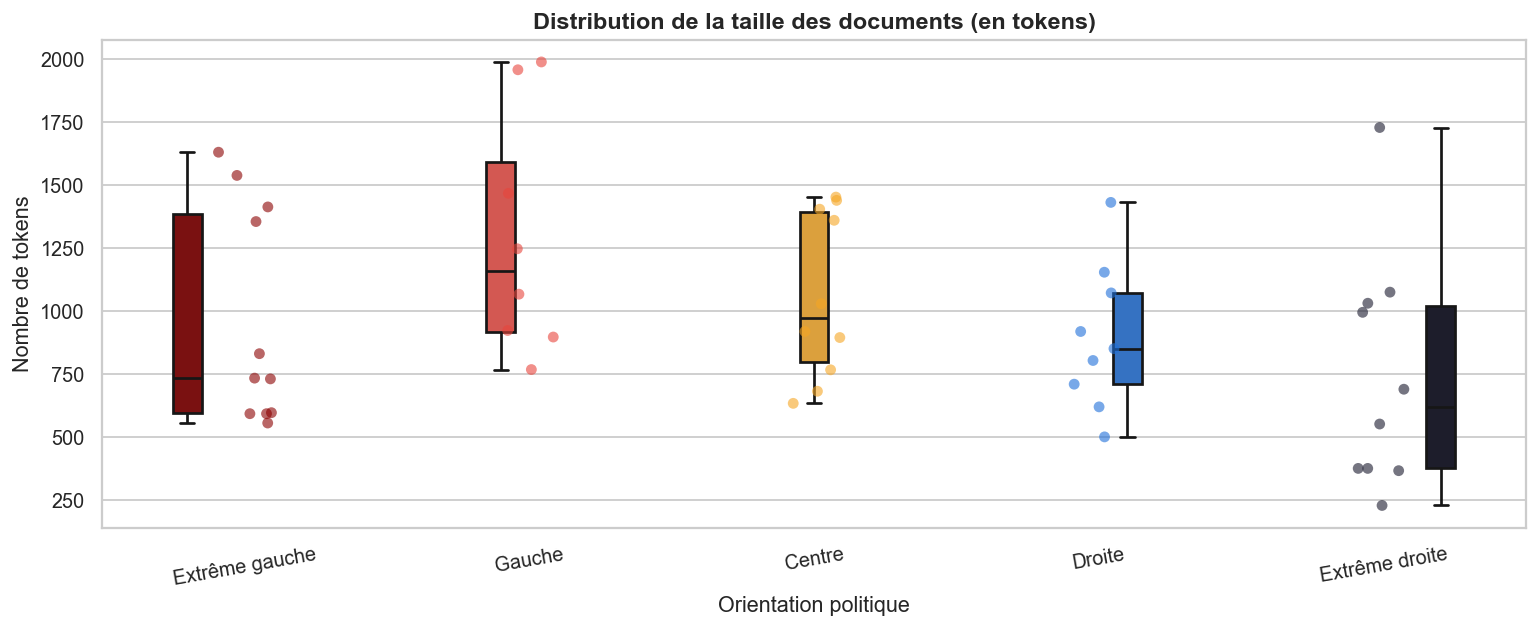

In [82]:
fig, ax = plt.subplots(figsize=(12, 5))

label_order = [LABEL_NAMES[y] for y in ORDER]
palette_names = {LABEL_NAMES[y]: COLORS[y] for y in ORDER}

df['label'] = pd.Categorical(df['label'], categories=label_order, ordered=True)

sns.boxplot(
    data=df[df['total_tokens'] > 0], x='label', y='total_tokens',
    order=label_order, palette=palette_names, hue='label', legend=False,
    width=0.5, linewidth=1.5, ax=ax
)
sns.stripplot(
    data=df[df['total_tokens'] > 0], x='label', y='total_tokens',
    order=label_order, palette=palette_names, hue='label', legend=False,
    alpha=0.6, jitter=True, size=6, ax=ax
)

ax.set_title('Distribution de la taille des documents (en tokens)', fontsize=13, fontweight='bold')
ax.set_xlabel('Orientation politique')
ax.set_ylabel('Nombre de tokens')
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
plt.tight_layout()
plt.savefig('figures/tokens_distribution_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Répartition thématique par label (stacked bar)

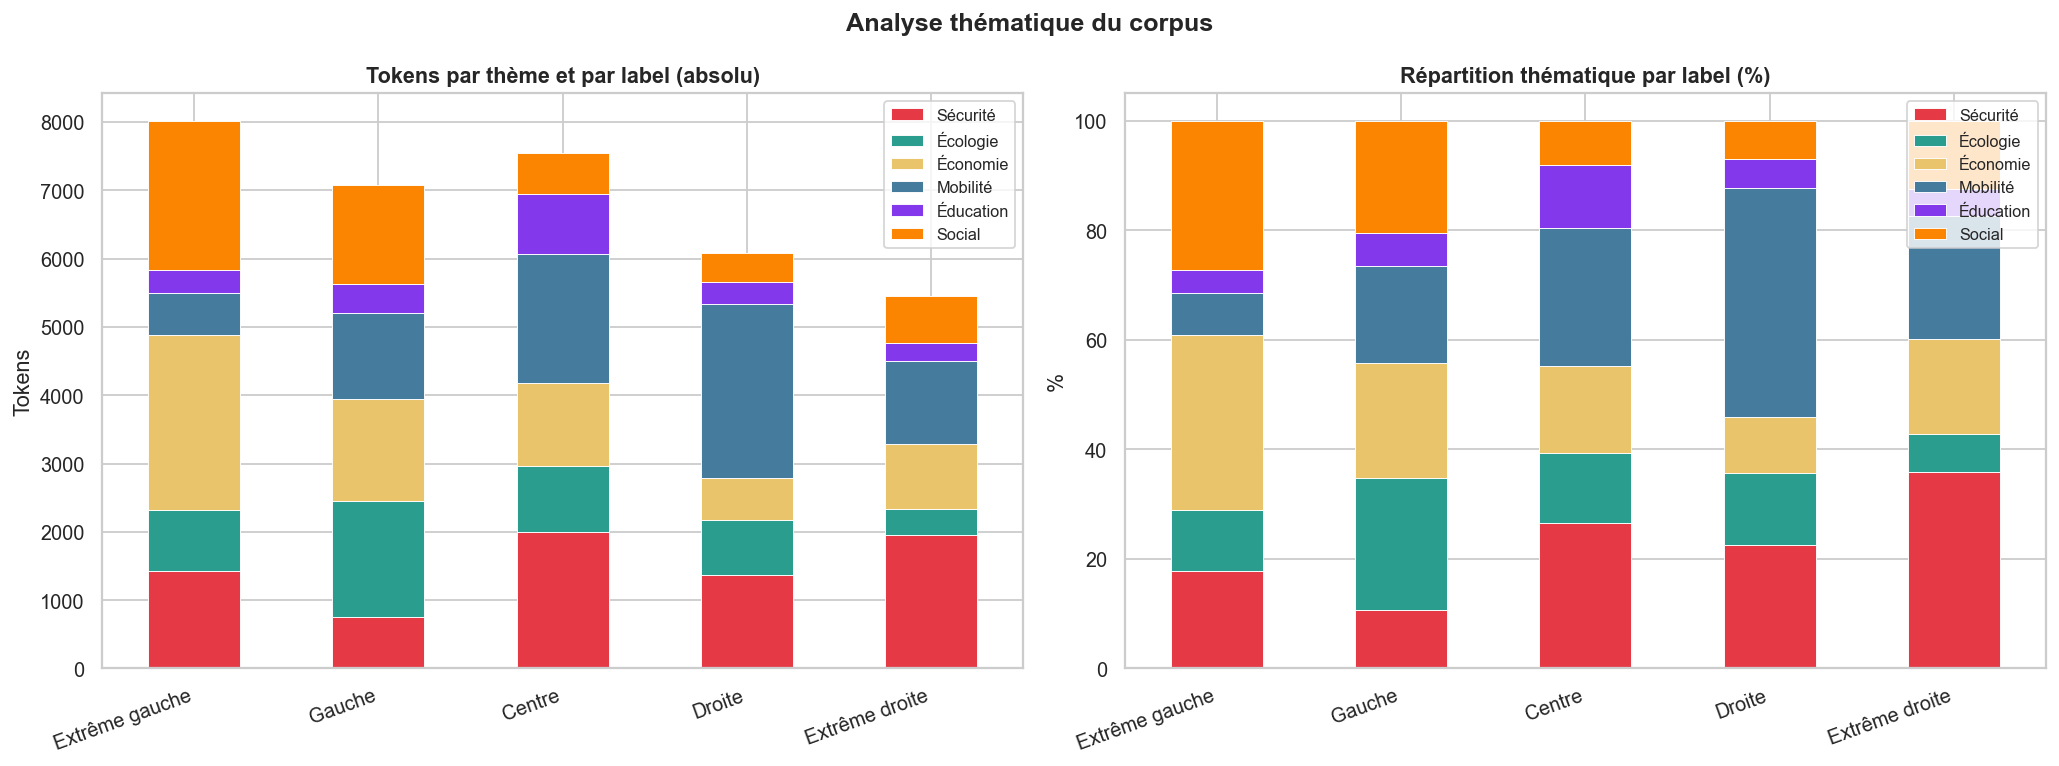

                Sécurité  Écologie  Économie  Mobilité  Éducation  Social
Extrême gauche      17.9      11.1      32.0       7.5        4.3    27.3
Gauche              10.7      24.0      21.1      17.7        6.0    20.6
Centre              26.5      12.8      16.0      25.1       11.6     8.1
Droite              22.5      13.1      10.2      41.9        5.3     7.0
Extrême droite      35.8       7.0      17.3      22.4        4.8    12.6


In [83]:
theme_cols = [f'tokens_{t}' for t in THEMES]
theme_by_label = df.groupby('y', observed=True)[theme_cols].sum()
theme_by_label.index = [LABEL_NAMES[y] for y in theme_by_label.index]
theme_by_label.columns = [THEME_LABELS[t] for t in THEMES]

theme_pct = theme_by_label.div(theme_by_label.sum(axis=1), axis=0) * 100

THEME_COLORS = ['#e63946','#2a9d8f','#e9c46a','#457b9d','#8338ec','#fb8500']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

theme_by_label.plot(kind='bar', stacked=True, ax=axes[0], color=THEME_COLORS,
                    edgecolor='white', linewidth=0.5)
axes[0].set_title('Tokens par thème et par label (absolu)', fontweight='bold')
axes[0].set_ylabel('Tokens')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].legend(loc='upper right', fontsize=9)

theme_pct.plot(kind='bar', stacked=True, ax=axes[1], color=THEME_COLORS,
               edgecolor='white', linewidth=0.5)
axes[1].set_title('Répartition thématique par label (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Analyse thématique du corpus', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/thematique.png', dpi=130, bbox_inches='tight')
plt.show()

print(theme_pct.round(1).to_string())

## 5. Heatmap thèmes × labels

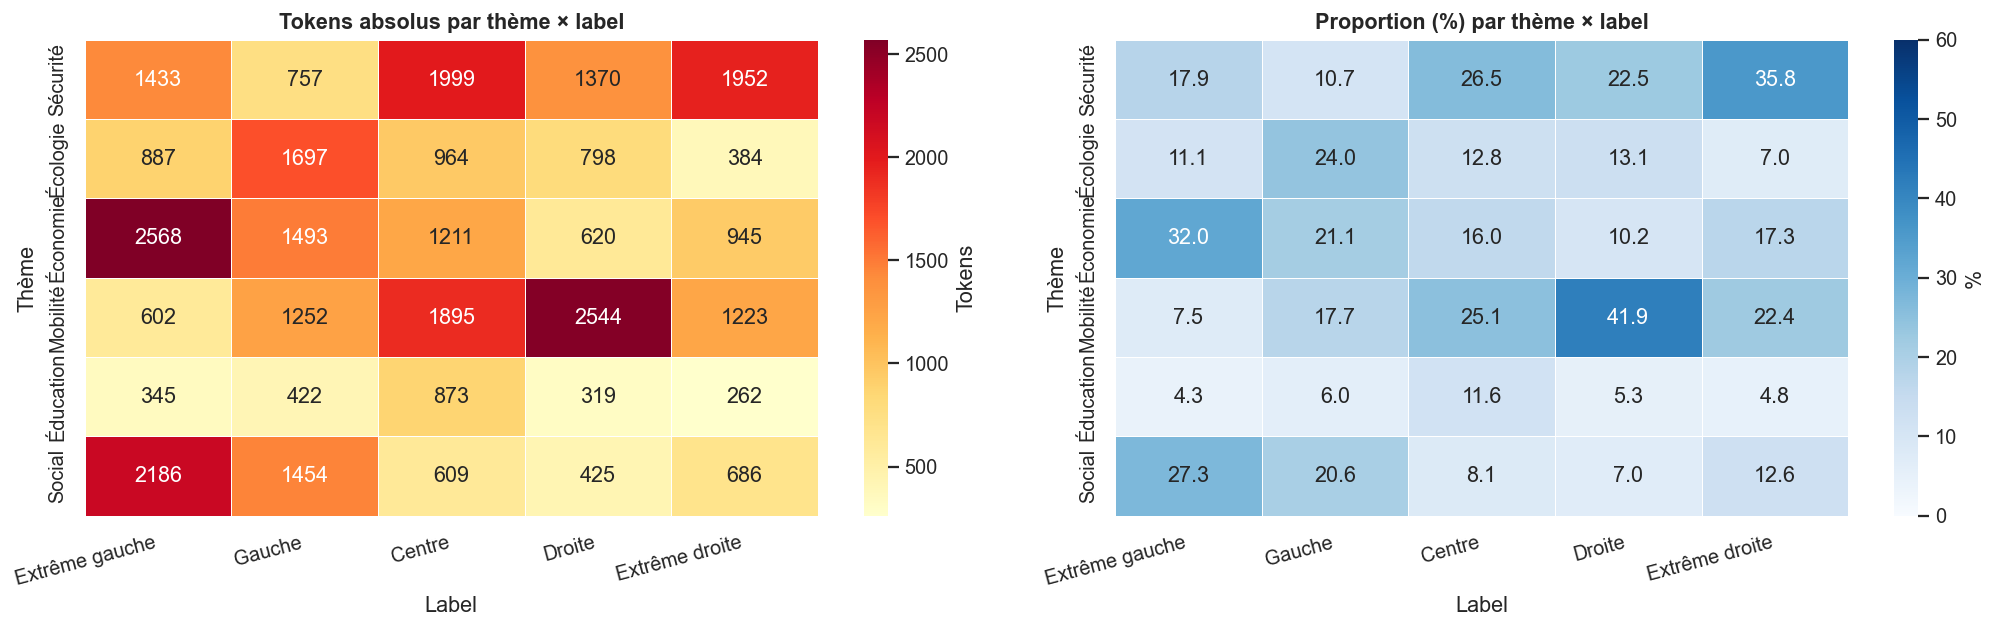

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap tokens absolus
sns.heatmap(
    theme_by_label.T, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Tokens'}
)
axes[0].set_title('Tokens absolus par thème × label', fontweight='bold')
axes[0].set_ylabel('Thème')
axes[0].set_xlabel('Label')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

# Heatmap %
sns.heatmap(
    theme_pct.T, annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.5, ax=axes[1], cbar_kws={'label': '%'}, vmin=0, vmax=60
)
axes[1].set_title('Proportion (%) par thème × label', fontweight='bold')
axes[1].set_ylabel('Thème')
axes[1].set_xlabel('Label')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.savefig('figures/theme_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Radar chart — profil thématique par label

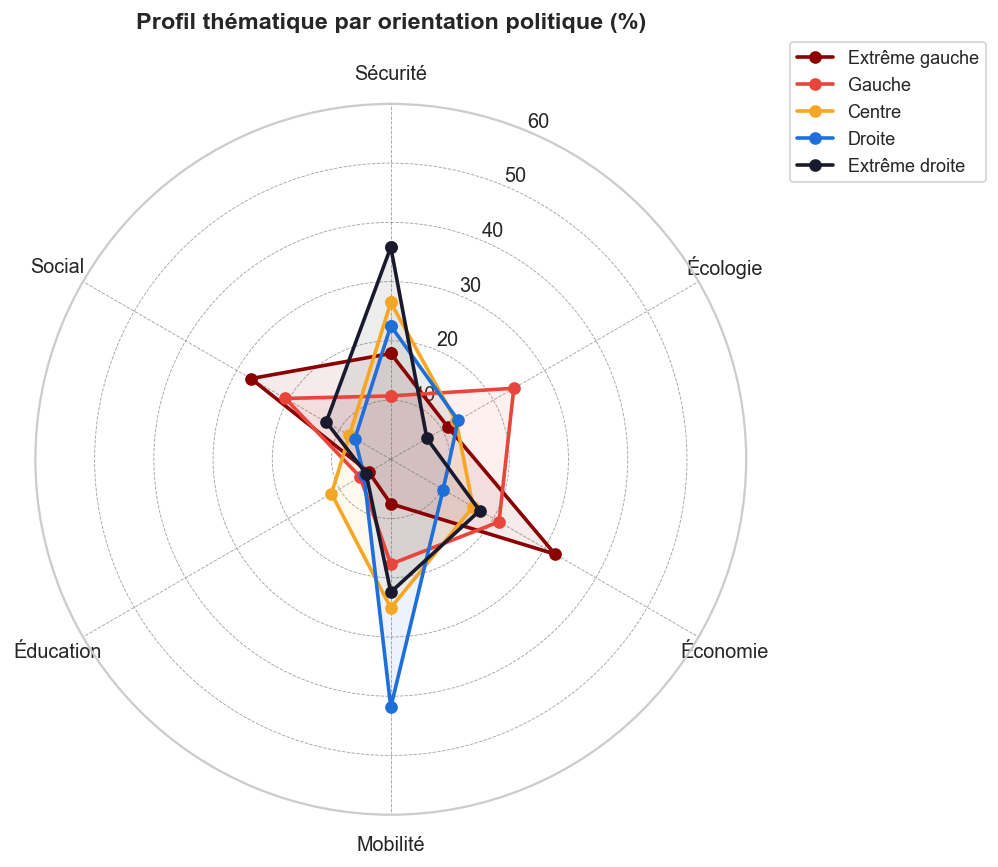

In [85]:
theme_names = list(THEME_LABELS.values())
N = len(theme_names)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for y in ORDER:
    label_name = LABEL_NAMES[y]
    if label_name not in theme_pct.index:
        continue
    values = theme_pct.loc[label_name].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=label_name, color=COLORS[y])
    ax.fill(angles, values, alpha=0.08, color=COLORS[y])

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), theme_names, fontsize=11)
ax.set_ylim(0, 60)
ax.set_title('Profil thématique par orientation politique (%)', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('figures/thematique_radar.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Taux de couverture thématique

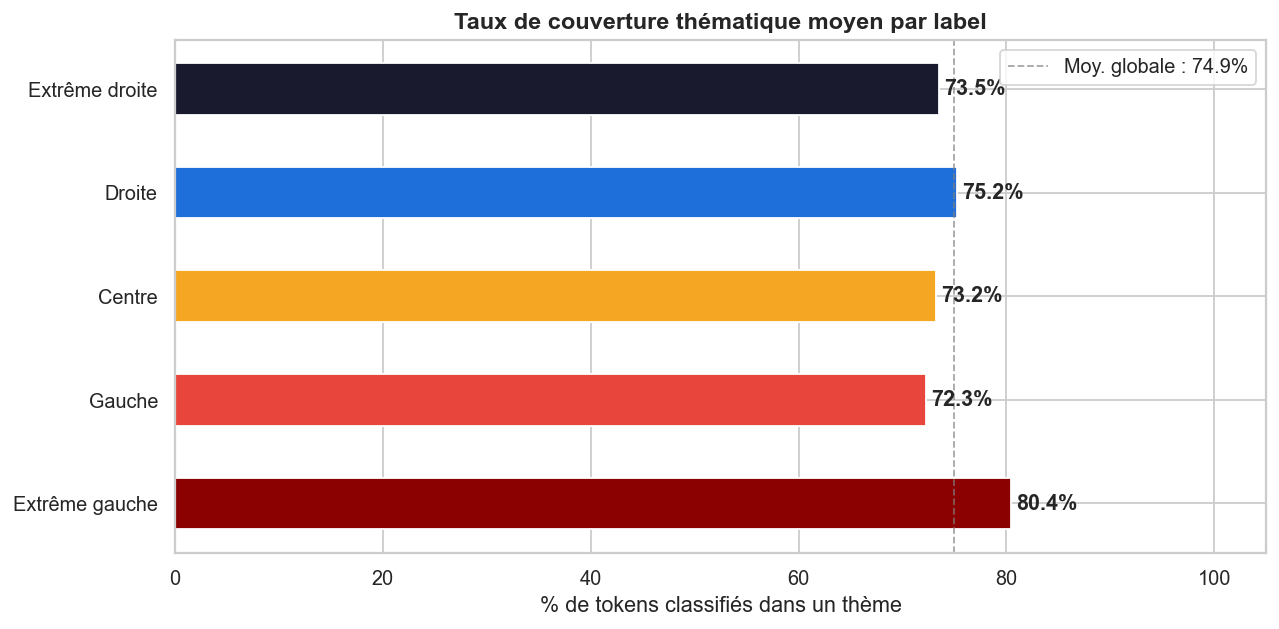

In [86]:
fig, ax = plt.subplots(figsize=(10, 5))

cov = df[df['total_tokens'] > 0].groupby('y', observed=True)['coverage_pct'].mean()
cov.index = [LABEL_NAMES[y] for y in cov.index]
cov = cov.reindex([LABEL_NAMES[y] for y in ORDER])

bars = ax.barh(cov.index, cov.values, color=[COLORS[y] for y in ORDER],
               edgecolor='white', height=0.5)

for bar, val in zip(bars, cov.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

ax.set_xlim(0, 105)
ax.set_xlabel('% de tokens classifiés dans un thème')
ax.set_title('Taux de couverture thématique moyen par label', fontweight='bold', fontsize=13)
ax.axvline(x=cov.mean(), color='grey', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Moy. globale : {cov.mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('figures/thematique_couverture%.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Nuages de mots par orientation politique

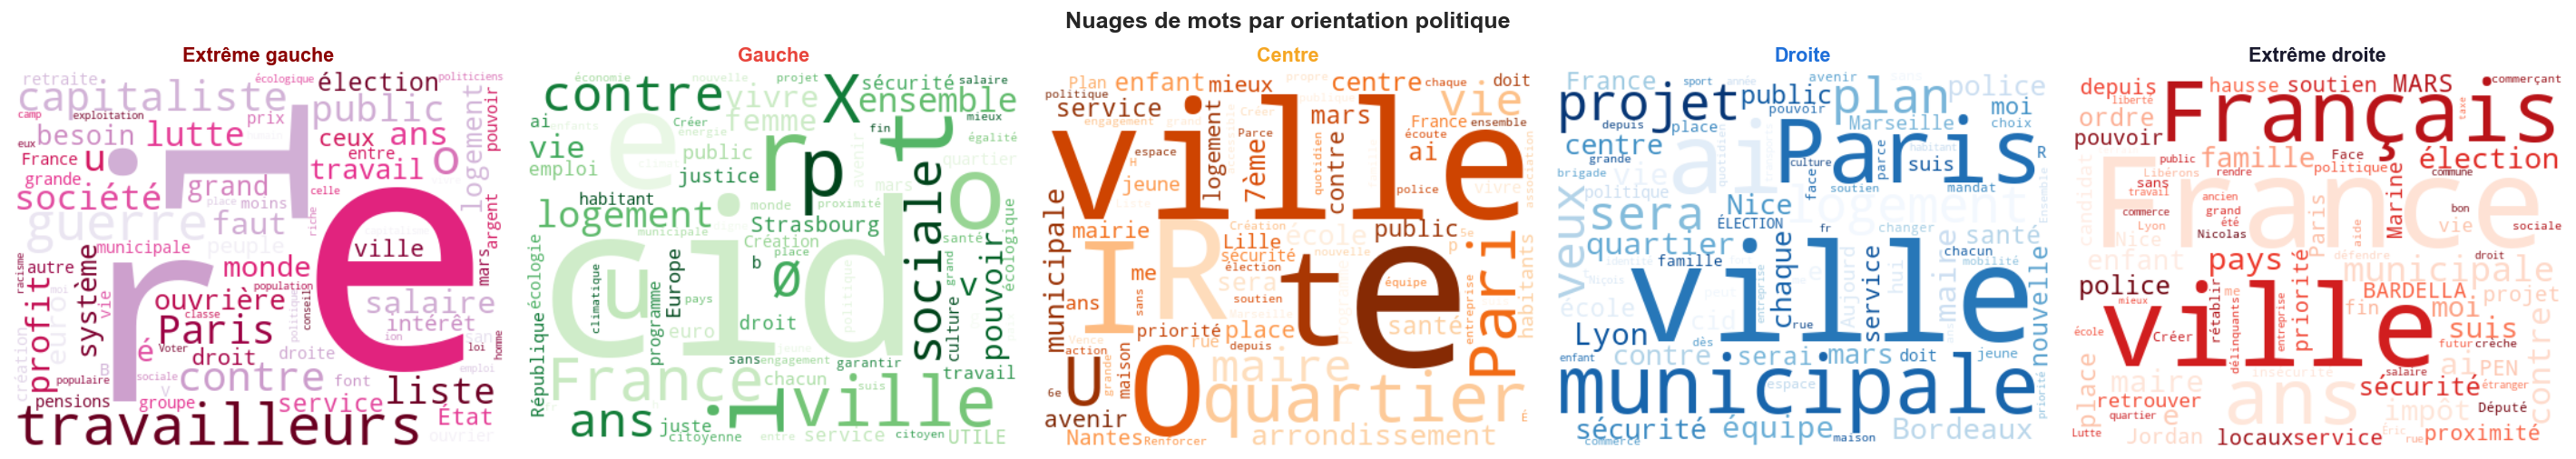

In [87]:
STOPWORDS_FR = set([
    'le','la','les','de','du','des','un','une','et','en','à','au','aux','par','pour',
    'sur','dans','qui','que','qu','il','ils','elle','elles','nous','vous','je','on',
    'ce','se','sa','son','ses','leur','leurs','mais','ou','donc','or','ni','car',
    'plus','est','sont','ont','être','avoir','avec','cette','ces','cet','tout',
    'tous','toute','toutes','notre','nos','vos','votre','y','ne','pas','si','très',
    'comme','même','aussi','bien','lors','dont','où','c','n','l','d','j','s','m',
    'a','an','fait','faire','mes','mon','ma','cette','cela','plus','après','avant'
])

CMAPS = {'ED':'Reds','D':'Blues','C':'Oranges','G':'Greens','EG':'PuRd'}

def get_text_for_label(y_code):
    docs = [d for d in all_docs if d.get('y') == y_code]
    texts = []
    for d in docs:
        for t in THEMES:
            texts.append(d.get('themes', {}).get(t, ''))
        texts.append(d.get('non_classe', ''))
    return ' '.join(texts)

fig, axes = plt.subplots(1, len(ORDER), figsize=(22, 4))

for ax, y in zip(axes, ORDER):
    text = get_text_for_label(y)
    if not text.strip():
        ax.axis('off')
        continue
    wc = WordCloud(
        width=420, height=320,
        background_color='white',
        stopwords=STOPWORDS_FR,
        colormap=CMAPS[y],
        max_words=80,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(LABEL_NAMES[y], fontweight='bold', color=COLORS[y], fontsize=12)
    ax.axis('off')

plt.suptitle('Nuages de mots par orientation politique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/nuage_de_mots.png', dpi=130, bbox_inches='tight')
plt.show()

## 9. Top 15 mots par thème (toutes orientations)

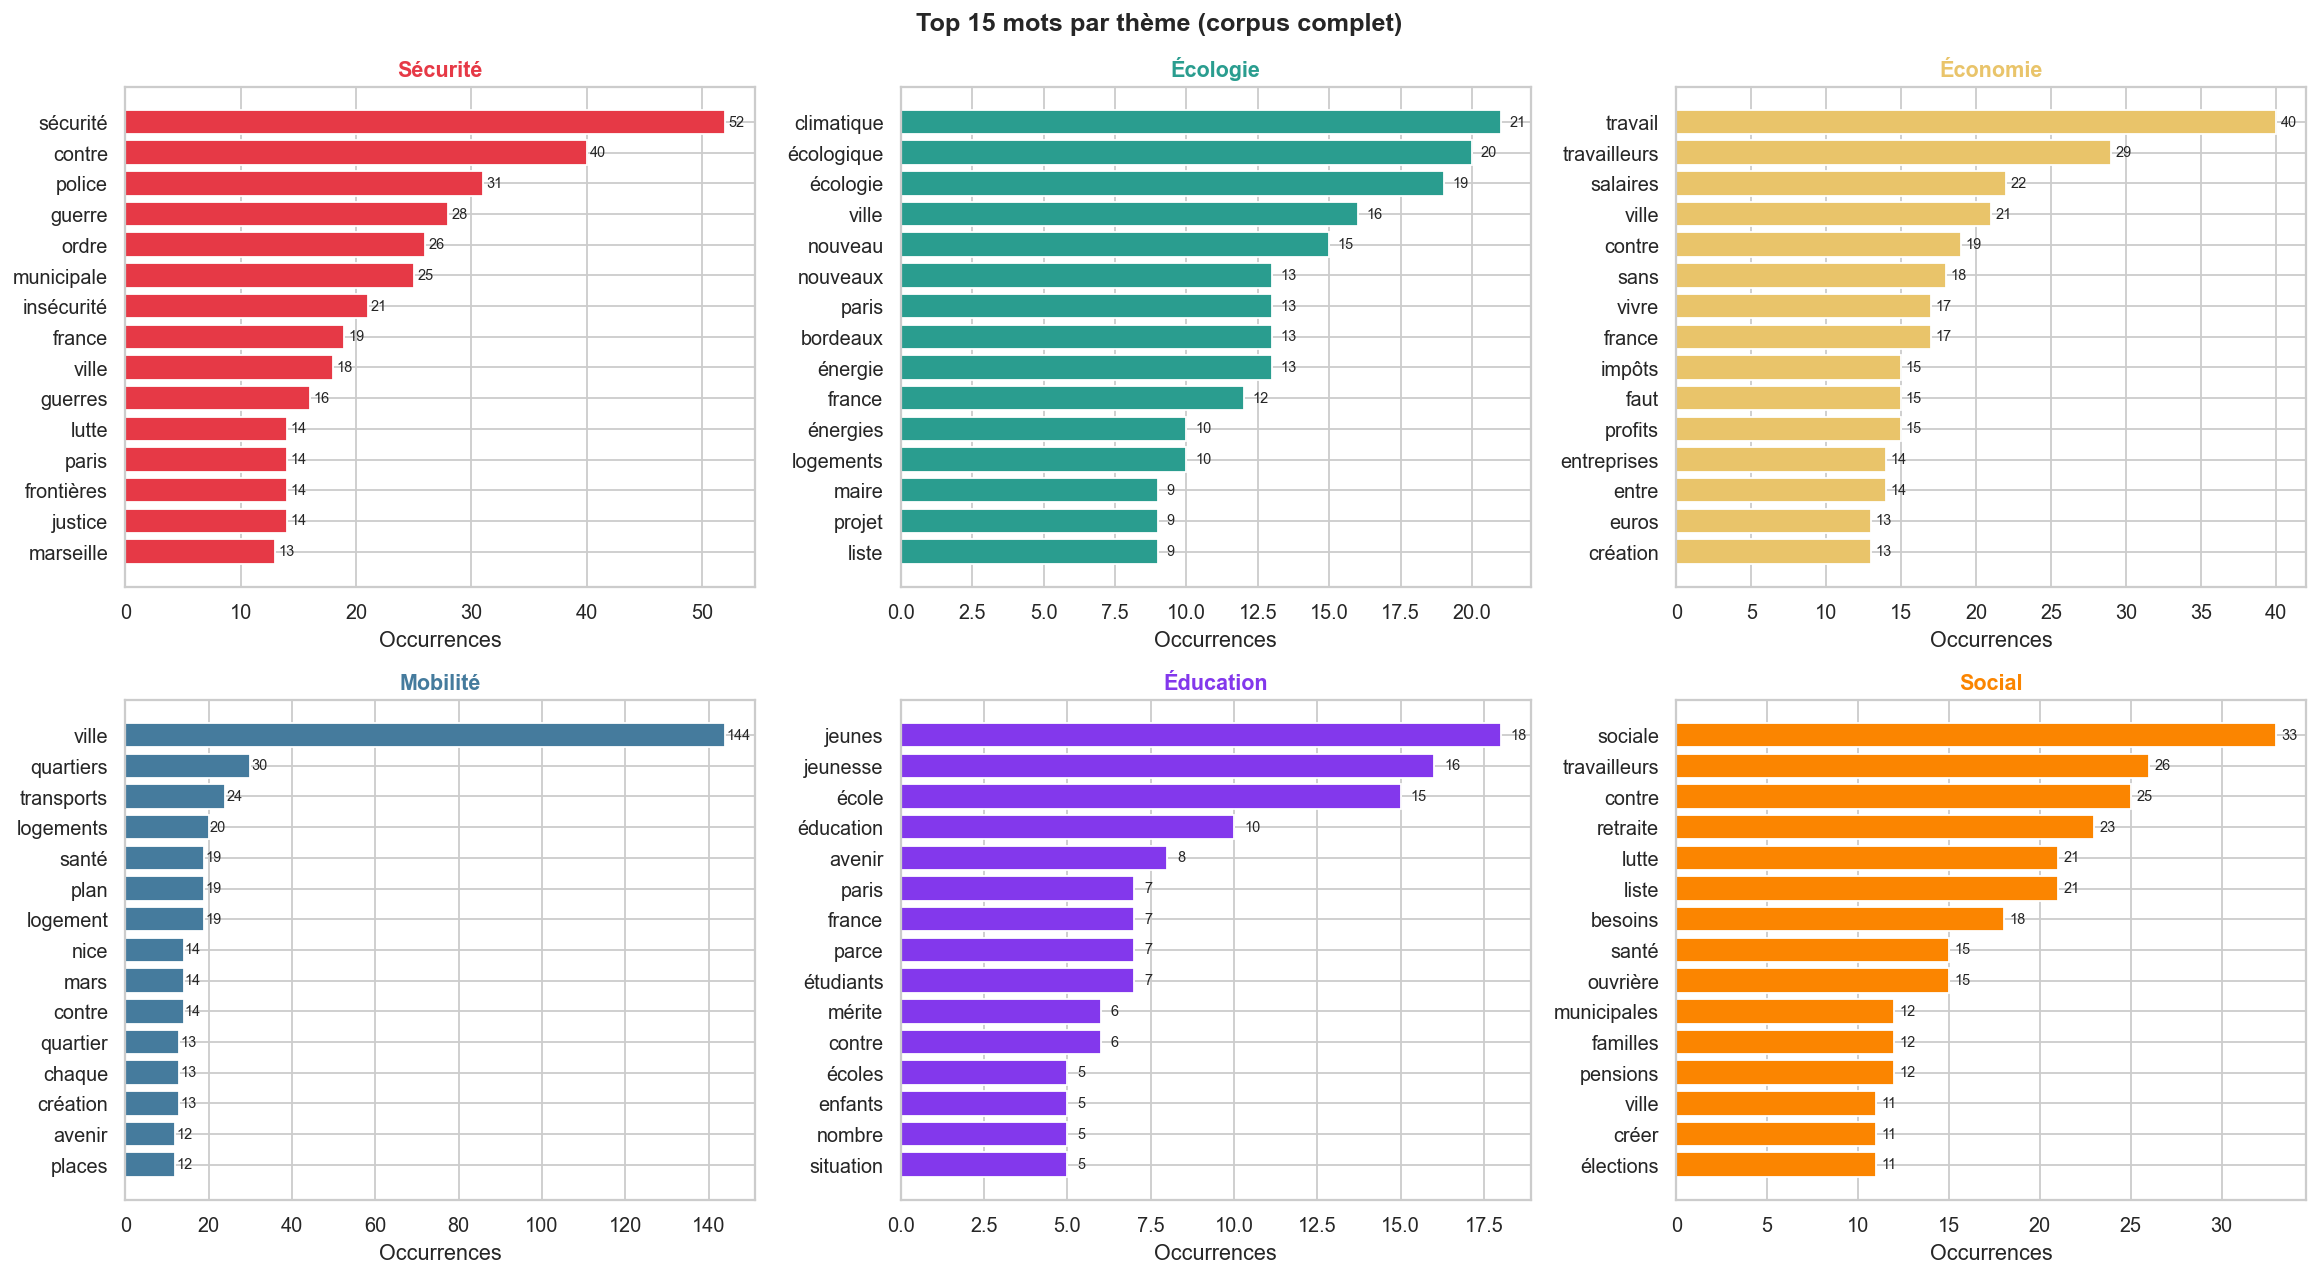

In [88]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
THEME_COLORS_MAP = dict(zip(THEMES, THEME_COLORS))

for ax, theme in zip(axes, THEMES):
    all_text = ' '.join(
        d.get('themes', {}).get(theme, '') for d in all_docs
    ).lower()
    words = [w for w in re.findall(r'[a-zàâçéèêëîïôùûü]+', all_text)
             if w not in STOPWORDS_FR and len(w) > 3]
    top = Counter(words).most_common(15)
    if not top:
        ax.axis('off')
        continue
    mots, counts = zip(*top)
    bars = ax.barh(list(reversed(mots)), list(reversed(counts)),
                   color=THEME_COLORS_MAP[theme], edgecolor='white')
    ax.set_title(f'{THEME_LABELS[theme]}', fontweight='bold', fontsize=12,
                 color=THEME_COLORS_MAP[theme])
    ax.set_xlabel('Occurrences')
    for bar, val in zip(bars, list(reversed(counts))):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)

plt.suptitle('Top 15 mots par thème (corpus complet)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/top_mots_par_theme.png', dpi=130, bbox_inches='tight')
plt.show()

## 10. Tableau récapitulatif

In [89]:
recap = df.groupby('y', observed=True).agg(
    docs=('id','count'),
    total_tokens=('total_tokens','sum'),
    moy_tokens=('total_tokens','mean'),
    coverage=('coverage_pct','mean'),
    **{THEME_LABELS[t]: (f'tokens_{t}', 'sum') for t in THEMES}
).round(1)

recap.index = [LABEL_NAMES[y] for y in recap.index]
recap.index.name = 'Label'
recap.columns = ['Docs','Total tokens','Moy tokens/doc','Coverage %'] + list(THEME_LABELS.values())
recap

,Docs,Total tokens,Moy tokens/doc,Coverage %,Sécurité,Écologie,Économie,Mobilité,Éducation,Social
Label,,,,,,,,,,
Extrême gauche,11,10571,961.0,80.4,1433,887,2568,602,345,2186
Gauche,8,10314,1289.2,72.3,757,1697,1493,1252,422,1454
Centre,12,10581,881.8,61.0,1999,964,1211,1895,873,609
Droite,10,8062,806.2,67.7,1370,798,620,2544,319,425
Extrême droite,10,7419,741.9,73.5,1952,384,945,1223,262,686


# Utilisation de TF-IDF

-> TF-IDF = fréquence dans le doc × log(nb total docs / nb docs contenant ce mot)
Permet de démarquer les mots qui sont très presents dans un bord politique et rares dans le corpus général aux mots très présents dans le corpus général.

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer

docs_etiquetes = [d for d in all_docs if d.get('y') and d['y'] != '?']
texts  = [' '.join(d['themes'].values()) for d in docs_etiquetes]
labels = [d['y'] for d in docs_etiquetes]

MOTS_A_FILTRER = {
    # Formes conjuguées d'être
    'suis', 'est', 'sommes', 'êtes', 'sont', 'sera', 'serai', 'serons',
    'serez', 'seront', 'étais', 'était', 'étions', 'étiez', 'étaient',
    # Formes conjuguées d'avoir
    'ai', 'as', 'avons', 'avez', 'ont', 'aurai', 'auras', 'aura',
    # Formes conjuguées de vouloir / pouvoir / faire
    'veux', 'veut', 'voulons', 'voulez', 'veulent',
    'peux', 'peut', 'pouvons', 'pouvez', 'peuvent',
    'fais', 'fait', 'faisons', 'faites', 'font', 'faut'
    # Mots génériques sans valeur idéologique
    'liste', 'listes', 'municipale', 'municipales', 'mars', 'vote',
    'candidat', 'candidats', 'ville', 'villes', 'maire', 'maires', 'cid', 'paris', 'marseille',
    # Noms propres de leaders politiques, bruit de parti, pas d'idéologie
    'marine', 'pen', 'bardella', 'jordan', 'melenchon', 'macron',
    'ciotti', 'zemmour', 'jadot',
    # Autres bruits
    '15', '22', '145'
}

STOPWORDS_COMPLETS = STOPWORDS_FR | MOTS_A_FILTRER

In [91]:
# vectorisation TF-IDF

vectorizer = TfidfVectorizer(
    max_features=1000,      # on garde les 1000 termes les plus importants
    min_df=2,               # ignore les mots qui n'apparaissent que dans 1 doc
    ngram_range=(1, 2),     # unigrammes ET bigrammes : "police municipale" > "police" seul
    stop_words=list(STOPWORDS_COMPLETS),
    lowercase=True,
    sublinear_tf=True       # utilise log(tf+1) au lieu de tf brut, pour éviter qu'un candidat avec plus de tokens, écrase les autres
)

X = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

print(f'Matrice : {X.shape}')  # (nb_docs x nb_termes)

Matrice : (51, 1000)


In [92]:
df_tfidf = pd.DataFrame(X.toarray(), columns=feature_names)
df_tfidf['bord'] = labels

# pour chaque bord
# score TF-IDF moyen de chaque mot sur tous ses documents
tfidf_par_bord = df_tfidf.groupby('bord').mean()

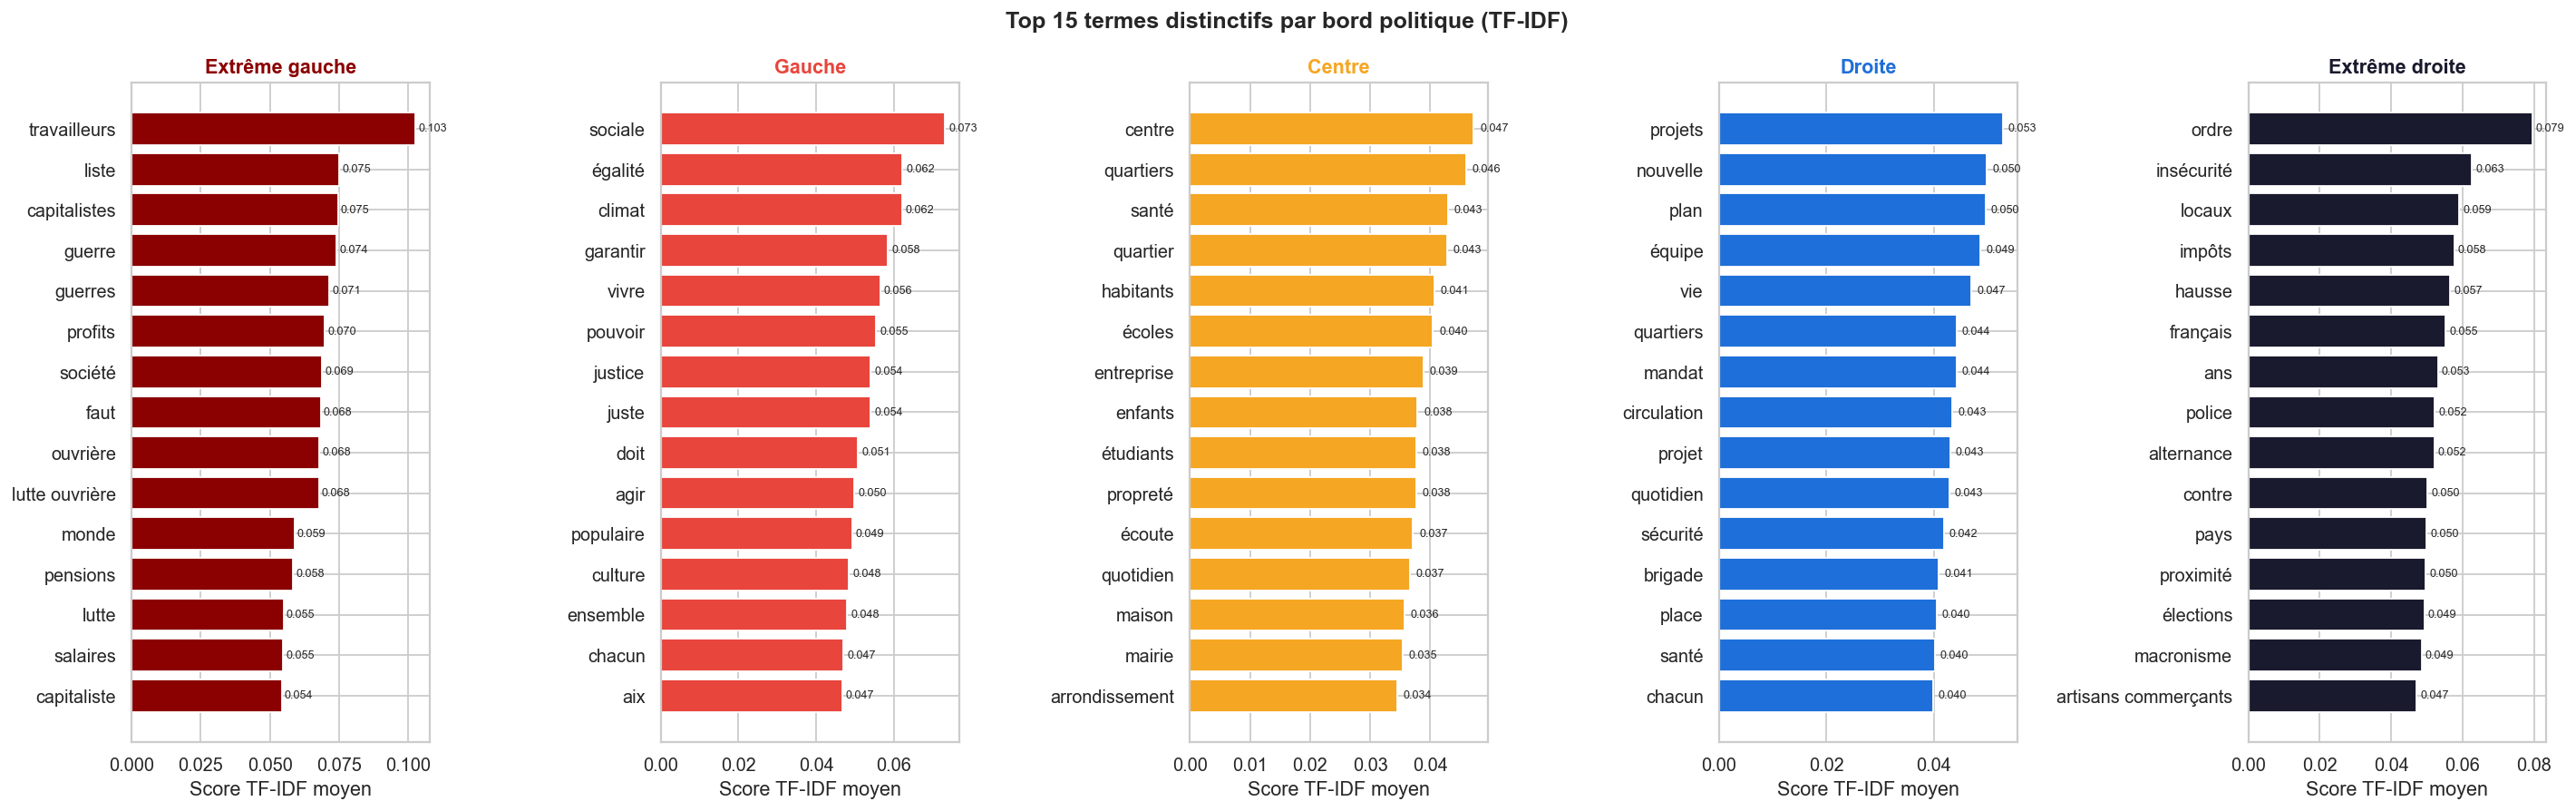

In [93]:
fig, axes = plt.subplots(1, 5, figsize=(22, 7))

for ax, bord in zip(axes, ORDER):
    if bord not in tfidf_par_bord.index:
        ax.axis('off')
        continue

    top = tfidf_par_bord.loc[bord].sort_values(ascending=False).head(15)

    bars = ax.barh(
        list(reversed(top.index)),
        list(reversed(top.values)),
        color=COLORS[bord],
        edgecolor='white'
    )

    for bar, val in zip(bars, list(reversed(top.values))):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=7)

    ax.set_title(LABEL_NAMES[bord], fontweight='bold', color=COLORS[bord])
    ax.set_xlabel('Score TF-IDF moyen')

plt.suptitle('Top 15 termes distinctifs par bord politique (TF-IDF)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/top_mots_par_theme_TF-IDF.png', dpi=130, bbox_inches='tight')
plt.show()

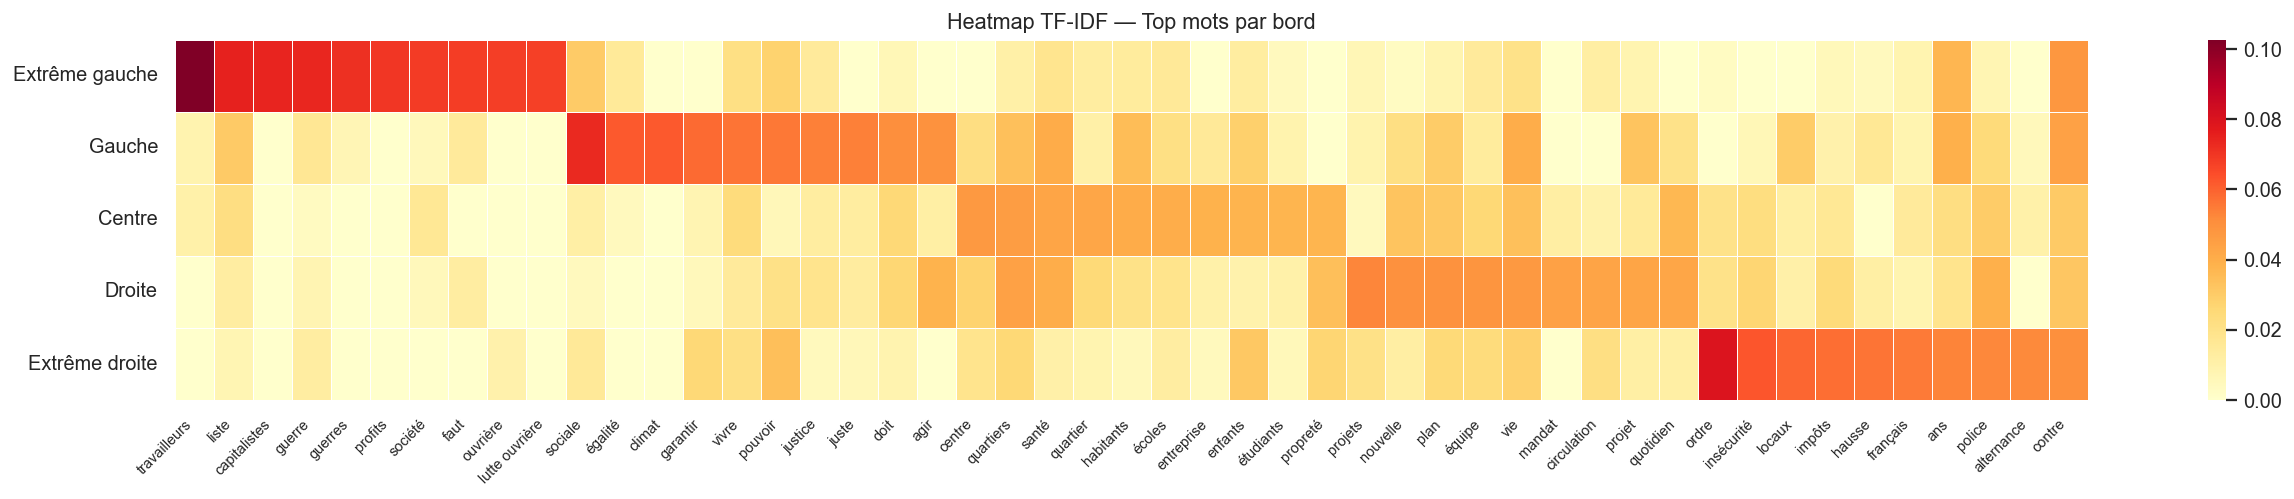

In [94]:
# Top 10 mots de chaque bord, sans doublons
top_mots = []
for bord in ORDER:
    if bord in tfidf_par_bord.index:
        top_mots += list(tfidf_par_bord.loc[bord].sort_values(ascending=False).head(10).index)
top_mots = list(dict.fromkeys(top_mots))

heatmap_data = tfidf_par_bord.loc[
    [b for b in ORDER if b in tfidf_par_bord.index],
    top_mots
]
heatmap_data.index = [LABEL_NAMES[b] for b in heatmap_data.index]

fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Heatmap TF-IDF — Top mots par bord')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('figures/heatmap_TF-IDF.png', dpi=130, bbox_inches='tight')
plt.show()

# Prédire le bord politique des candidats

Régression linéaire : probabilité par bord pour chaque candidat

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

clf = LogisticRegression(
    max_iter=1000,
    C=1.0,           # force de régularisation
    solver='lbfgs',  # car petit corpus multiclasse
    class_weight='balanced',  # pénaliser les erreurs sur la classe minoritaire (gauche) pour compenser le déséquilibre du corpus
)

clf.fit(X, labels)
print("Classifieur entraîné.")
print(f"Classes : {clf.classes_}")

Classifieur entraîné.
Classes : ['C' 'D' 'ED' 'EG' 'G']


# Validation croisée 5-fold

on entraine 5 fois sur des partitions différents puis on moyenne les resulats

In [96]:
scores = cross_val_score(clf, X, labels, cv=5, scoring='accuracy')

print(f"Accuracy moyenne : {scores.mean():.2%}")
print(f"Écart-type       : {scores.std():.2%}")
print(f"Scores par fold  : {[f'{s:.2%}' for s in scores]}")

Accuracy moyenne : 49.45%
Écart-type       : 19.57%
Scores par fold  : ['27.27%', '50.00%', '80.00%', '60.00%', '30.00%']


In [97]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = cross_val_predict(clf, X, labels, cv=5)

print(classification_report(
    labels, y_pred,
    target_names=[LABEL_NAMES[b] for b in clf.classes_]
))

                precision    recall  f1-score   support

        Centre       0.27      0.33      0.30        12
        Droite       0.25      0.30      0.27        10
Extrême droite       1.00      0.70      0.82        10
Extrême gauche       1.00      0.64      0.78        11
        Gauche       0.40      0.50      0.44         8

      accuracy                           0.49        51
     macro avg       0.58      0.49      0.52        51
  weighted avg       0.59      0.49      0.52        51



Prédit très mal le centre (30%) et la droite (27%) et très bien l'extrème droite (82%) et l'extrème gauche (78%)

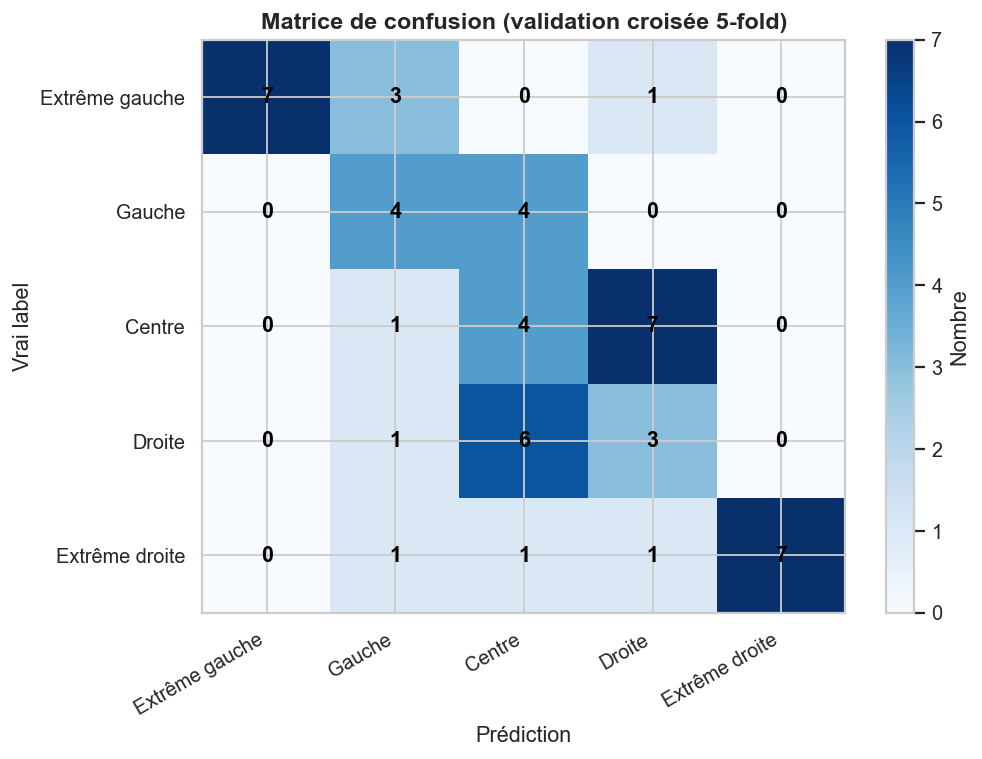

In [99]:
from sklearn.metrics import confusion_matrix

# Réorganiser les prédictions selon ORDER
y_pred_ordered = []
y_true_ordered = []
label_to_code = {LABEL_NAMES[k]: k for k in LABEL_NAMES}

for true_label, pred_label in zip(labels, y_pred):
    y_true_ordered.append(true_label)
    y_pred_ordered.append(pred_label)

# Créer la matrice de confusion avec l'ordre défini
cm = confusion_matrix(y_true_ordered, y_pred_ordered, labels=ORDER)

fig, ax = plt.subplots(figsize=(8, 6))

# Afficher la matrice avec les labels dans le bon ordre
im = ax.imshow(cm, cmap='Blues', aspect='auto')

# Définir les labels et ticks
labels_list = [LABEL_NAMES[b] for b in ORDER]
ax.set_xticks(range(len(ORDER)))
ax.set_yticks(range(len(ORDER)))
ax.set_xticklabels(labels_list, rotation=30, ha='right')
ax.set_yticklabels(labels_list)

# Ajouter les valeurs dans les cellules
for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center", color="black", fontweight='bold')

ax.set_xlabel('Prédiction')
ax.set_ylabel('Vrai label')
ax.set_title('Matrice de confusion (validation croisée 5-fold)',
             fontweight='bold', fontsize=13)

plt.colorbar(im, ax=ax, label='Nombre')
plt.tight_layout()
plt.savefig('figures/reg_lin_matrice_confusion.png', dpi=130, bbox_inches='tight')
plt.show()

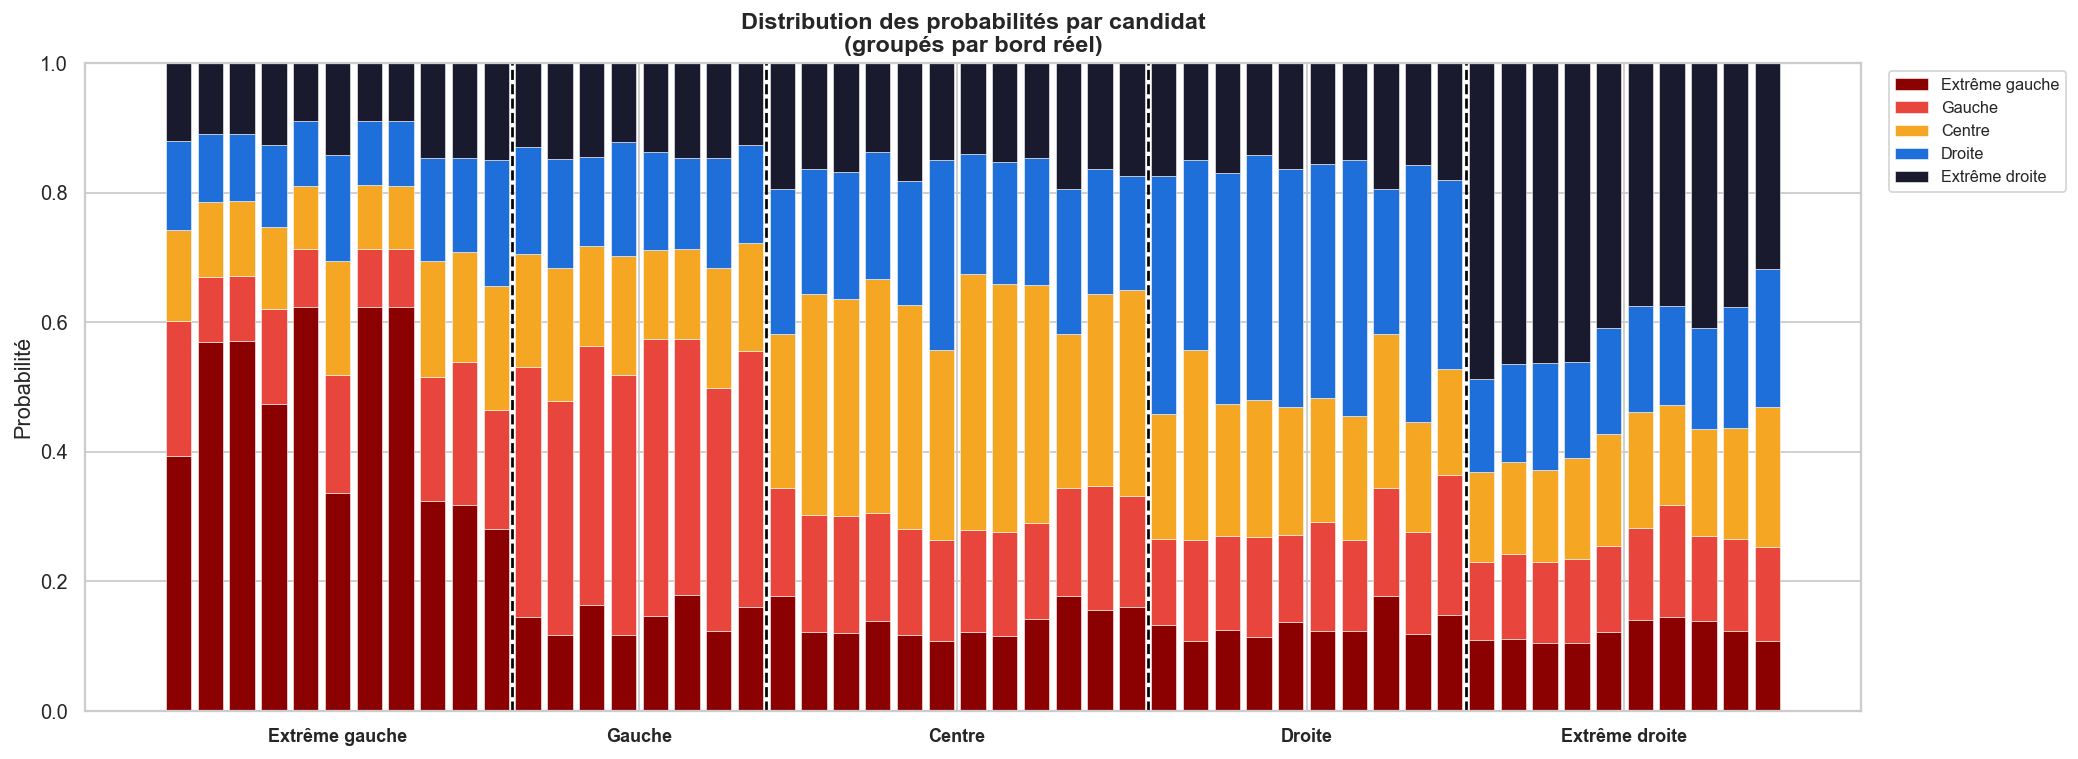

In [100]:
probas = clf.predict_proba(X)
df_probas = pd.DataFrame(probas, columns=[LABEL_NAMES[b] for b in clf.classes_])
df_probas['vrai_bord'] = [LABEL_NAMES[l] for l in labels]
df_probas['correct'] = [LABEL_NAMES[p] == LABEL_NAMES[l] 
                         for p, l in zip(clf.predict(X), labels)]

# Trier selon l'ordre politique défini dans ORDER
bord_order_names = [LABEL_NAMES[b] for b in ORDER]
df_probas['vrai_bord_cat'] = pd.Categorical(df_probas['vrai_bord'], 
                                            categories=bord_order_names, 
                                            ordered=True)
df_probas = df_probas.sort_values('vrai_bord_cat').reset_index(drop=True)
df_probas = df_probas.drop('vrai_bord_cat', axis=1)

fig, ax = plt.subplots(figsize=(16, 6))

bottom = np.zeros(len(df_probas))
bords_ordre = [LABEL_NAMES[b] for b in ORDER]
colors_labels = [COLORS[b] for b in ORDER]

for bord, color in zip(bords_ordre, colors_labels):
    vals = df_probas[bord].values
    ax.bar(range(len(df_probas)), vals, bottom=bottom,
           label=bord, color=color, edgecolor='white', linewidth=0.3)
    bottom += vals

# Ligne verticale pour séparer les bords réels
bord_col = df_probas['vrai_bord']
for i in range(1, len(bord_col)):
    if bord_col.iloc[i] != bord_col.iloc[i-1]:
        ax.axvline(x=i - 0.5, color='black', linewidth=1.5, linestyle='--')

# Étiquettes des vrais bords en dessous
bord_positions = []
bord_names = []
start = 0
for i in range(1, len(bord_col)):
    if bord_col.iloc[i] != bord_col.iloc[i-1]:
        bord_positions.append((start + i - 1) / 2)
        bord_names.append(bord_col.iloc[start])
        start = i
bord_positions.append((start + len(bord_col) - 1) / 2)
bord_names.append(bord_col.iloc[start])

ax.set_xticks(bord_positions)
ax.set_xticklabels(bord_names, fontsize=10, fontweight='bold')
ax.set_ylabel('Probabilité')
ax.set_ylim(0, 1)
ax.set_title('Distribution des probabilités par candidat\n(groupés par bord réel)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.12, 1), fontsize=9)
plt.tight_layout()
plt.savefig('figures/probas_par_candidat.png', dpi=130, bbox_inches='tight')
plt.show()